<h1 align=center style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
دایی موند
</font>
</h1>

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مقدمه و صورت مسئله
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
    به اولین تمرین از فصل‌های مدل‌سازی کالج خوش‌آمدید 😊🎉
    <br>
    هدف ما در این مسئله این است که قیمت الماس‌ها را بر اساس تعدادی از ویژگی‌های آن‌ها پیش‌بینی کنیم.
    برای حل این مسئله به سراغ الگوریتم رگرسیون خطی خواهیم رفت.
</font>
</p>

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
وارد کردن کتابخانه‌های مورد نیاز
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazir" size=3>
    ابتدا کتابخانه‌های مورد نیازتان را وارد کنید.
</font>
</p>

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
معرفی مجموعه‌داده
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
مجموعه‌داده‌ آموزشی‌ای که در اختیار داریم شامل ۱۰ ستون است که در جدول زیر، توضیحات هر کدام از ستون‌ها آورده شده است.
</font>
</p>

<center>
<div dir=rtl style="direction: rtl;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
    
|ستون|توضیحات|
|:------:|:---:|
|<code>carat</code>|وزن الماس به معیار قیراط|
|<code>cut</code>|کیفیت تراش‌خوردگی الماس|
|<code>color</code>|رنگ الماس از J(بدترین) تا D (بهترین)|
|<code>clarity</code>|معیار شفافیت الماس (از چپ به راست از بدترین به بهترین: I1, SI2, SI1, VS2, VS1, VVS2, VVS1, IF)
|<code>x</code>|طول الماس به میلی‌متر|
|<code>y</code>|عرض الماس به میلی‌متر|
|<code>z</code>|عمق الماس به میلی‌متر|
|<code>depth</code>|عمق درصدی که برابر است با z / mean(x,y)|
|<code>table</code>|عرض عریض‌ترین نقطه بالایی الماس|
|<code>price</code>|قیمت الماس|

</font>
</div>
</center>

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
خواندن مجموعه داده
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazir" size=3>
    در ابتدا نیاز است فایل‌های مجموعه‌داده را بخوانید. نمونه‌های آموزشی در فایل <code>diamonds_train.csv</code> و نمونه‌های آزمون که باید قیمت آن‌ها را پیش‌بینی کنید در فایل <code>diamonds_test.csv</code> ذخیره شده‌اند. اگر لازم دانستید می‌توانید به دلخواه خود بخشی از مجموعه‌ی آموزشی را به عنوان مجموعه‌ی اعتبارسنجی نیز جدا کنید.
</font>
</p>

In [2]:
train = pd.read_csv('../data/diamonds_train.csv')
train.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
test = pd.read_csv('../data/diamonds_test.csv') # TO-DO
test.head()

,carat,cut,color,clarity,depth,table,x,y,z
0,0.73,Ideal,G,VVS2,61.9,55.0,5.83,5.77,3.59
1,0.61,Premium,F,VVS2,59.7,58.0,5.56,5.53,3.31
2,1.55,Premium,I,VS1,58.2,60.0,7.69,7.59,4.45
3,0.46,Good,F,IF,56.2,61.0,5.16,5.24,2.92
4,1.10,Very Good,F,VS2,60.6,58.0,6.67,6.77,4.07


In [4]:
df_val = test.copy()
df_val.head(10)

,carat,cut,color,clarity,depth,table,x,y,z
0,0.73,Ideal,G,VVS2,61.9,55.0,5.83,5.77,3.59
1,0.61,Premium,F,VVS2,59.7,58.0,5.56,5.53,3.31
2,1.55,Premium,I,VS1,58.2,60.0,7.69,7.59,4.45
3,0.46,Good,F,IF,56.2,61.0,5.16,5.24,2.92
4,1.10,Very Good,F,VS2,60.6,58.0,6.67,6.77,4.07
5,0.30,Premium,G,VVS1,59.8,62.0,4.36,4.33,2.60
6,0.70,Very Good,F,SI1,60.3,59.0,5.73,5.78,3.47
7,0.66,Ideal,E,SI2,62.4,56.0,5.61,5.55,3.48
8,1.02,Ideal,D,SI2,58.9,61.0,6.56,6.62,3.88
9,0.32,Ideal,D,SI1,62.5,54.0,4.41,4.39,2.75


<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">

</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
    در این سوال شما می‌توانید از هر تکنیک پیش‌پردازش/مهندسی ویژگی که در فصل‌های گذشته آموختید، استفاده کنید.
    <br>
    تکنیک‌هایی که استفاده می‌کنید به شکل مستقیم مورد ارزیابی توسط سامانه داوری قرار <b>نمی‌گیرند.</b> بلکه همه آن‌ها در دقت مدل شما تاثیر خواهند گذاشت؛ بنابراین هر چه پیش‌پردازش/مهندسی ویژگی بهتری انجام دهید تا دقت مدل بهبود پیدا کند، امتیاز بیشتری از این سوال کسب خواهید کرد.
</font>
</p>

In [5]:
# len(df) = 50000

# Do some preprocessing!
df = train.copy()

# do to this line's result we don't have any missed value in DF
df.isnull().sum() 

# sum of duplicated data = 126
df.duplicated().sum()
df = df.drop_duplicates()



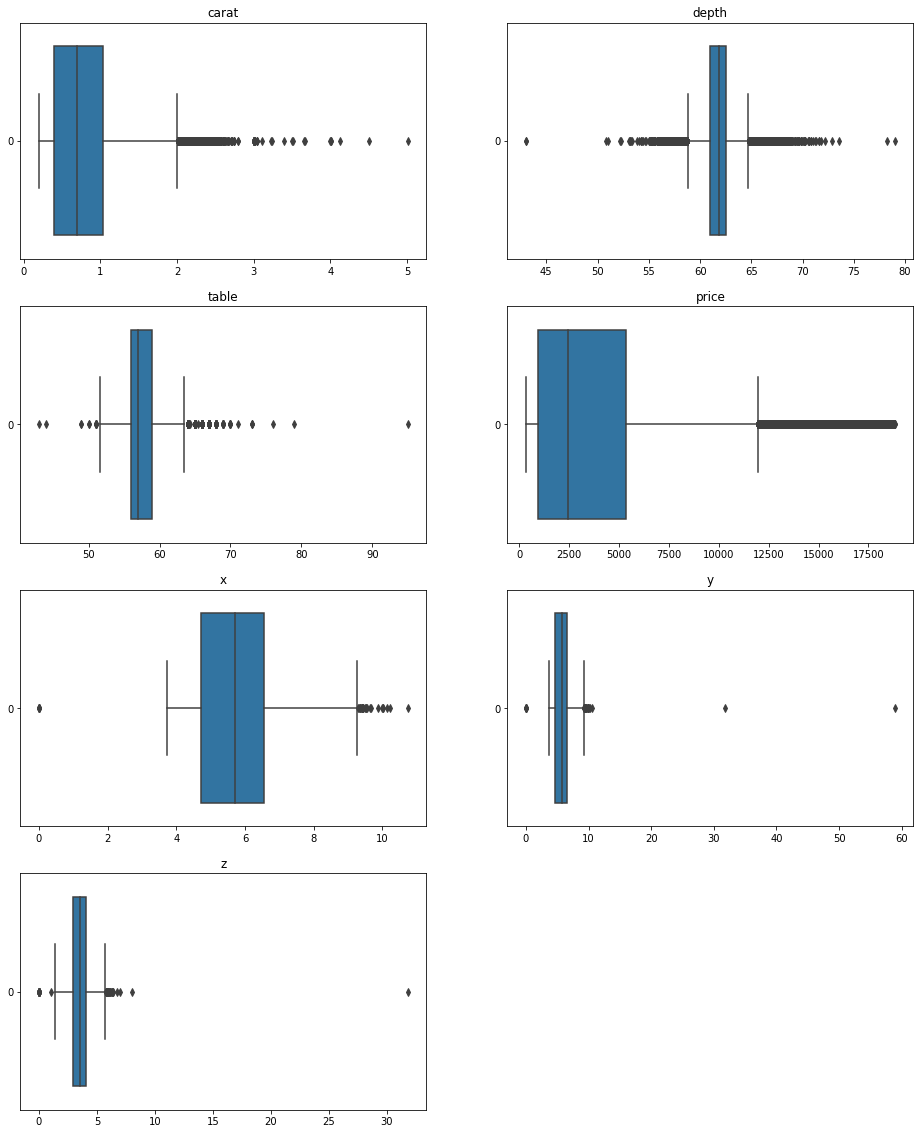

In [6]:
plt.figure(figsize=(16,20))
plt.subplot(4,2,1)
sns.boxplot(df['carat'],orient="horizontal")
plt.title('carat')
plt.subplot(4,2,2)
sns.boxplot(df['depth'],orient="horizontal")
plt.title('depth')
plt.subplot(4,2,3)
sns.boxplot(df['table'],orient="horizontal")
plt.title('table')
plt.subplot(4,2,4)
sns.boxplot(df['price'],orient="horizontal")
plt.title('price')
plt.subplot(4,2,5)
sns.boxplot(df['x'],orient="horizontal")
plt.title('x')
plt.subplot(4,2,6)
sns.boxplot(df['y'],orient="horizontal")
plt.title('y')
plt.subplot(4,2,7)
sns.boxplot(df['z'],orient="horizontal")
plt.title('z')
plt.show()

Notes of BoxPlots figure:
1.X,Y and Z have some 0 values. If the number of rows in these columns that have a value of 0 is small, we may consider dropping them from the dataset.
2. Depth has many outliers, but after observing its distribution, we found that it follows a normal distribution. Therefore, we can use z-score to manage the outliers.
3.Carat and Price have outliers but their distribution it's like gamma. 
4. Some unusual data points have been observed in the higher values of Y and Z. These data points appear to be noisy.

In [4]:
import warnings
warnings.filterwarnings('ignore')


plt.figure(figsize=(16,20))

plt.subplot(4,2,1)
sns.distplot(df['carat'])

plt.subplot(4,2,2)
sns.distplot(df['depth'])

plt.subplot(4,2,3)
sns.distplot(df['table'])

plt.subplot(4,2,4)
sns.distplot(df['price'])

plt.subplot(4,2,5)
sns.distplot(df['x'])

plt.subplot(4,2,6)
sns.distplot(df['y'])

plt.subplot(4,2,7)
sns.distplot(df['z'])

plt.show()

NameError: name 'plt' is not defined

Depth is Normal So:

In [8]:
#depth feature is normal So we use z-score for detection of outliers

upper_limit = df['depth'].mean() + 3*df['depth'].std()
lower_limit = df['depth'].mean() - 3*df['depth'].std()

print('Highest allowed',upper_limit)
print('Lowest allowed',lower_limit)

df['depth'] = np.where(df['depth']>upper_limit,upper_limit,np.where(df['depth']<lower_limit,lower_limit,df['depth']))

Highest allowed 66.0364225455612
Lowest allowed 57.46718253925254


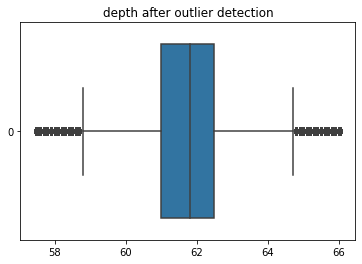

In [9]:
plt.figure()
sns.boxplot(df['depth'],orient="horizontal")
plt.title('depth after outlier detection')
plt.show()

Now we plot pairplot of numerical columns:

In [10]:
train.describe()

,carat,depth,table,price,x,y,z
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,0.799444,61.753006,57.457830,3944.805440,5.734403,5.737956,3.541056
std,0.475173,1.431088,2.232092,3997.938105,1.123077,1.145579,0.707065
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,951.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2410.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5351.000000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [11]:

print(train[train.z == train.z.max()])

print(train[train.x == train.x.max()])

print(train[train.y == train.y.max()])


       carat        cut color clarity  depth  table  price     x     y     z
44840   0.51  Very Good     E     VS1   61.8   54.7   1970  5.12  5.15  31.8
       carat   cut color clarity  depth  table  price      x      y     z
25426   5.01  Fair     J      I1   65.5   59.0  18018  10.74  10.54  6.98
       carat      cut color clarity  depth  table  price     x     y     z
22295    2.0  Premium     H     SI2   58.9   57.0  12210  8.09  58.9  8.06


Out of these three rows, rows number 44840 and 22295 appear to be incorrect as they have unusual values for Y and Z, but their prices are not very high. These data points may need to be reviewed and potentially corrected. Considering that we have a dataset of 5000 rows, dropping two rows should not pose a problem. Therefore, we have decided to remove these two rows from the dataset.


In [12]:
max_y = df[df.y == df.y.max()]
df = df.drop(max_y.index)
max_z = df[df.z == df.z.max()]
df = df.drop(max_z.index)

In [13]:
df.describe()

,carat,depth,table,price,x,y,z
count,49872.000000,49872.000000,49872.000000,49872.000000,49872.000000,49872.000000,49872.000000
mean,0.799313,61.748250,57.458851,3945.258462,5.734406,5.737006,3.540371
std,0.474584,1.361744,2.231097,3996.838353,1.122309,1.119972,0.694903
min,0.200000,57.467183,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,952.000000,4.720000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2414.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5352.000000,6.540000,6.540000,4.040000
max,5.010000,66.036423,95.000000,18823.000000,10.740000,31.800000,6.980000


In [14]:
print(df[df.y == df.y.max()])

       carat    cut color clarity  depth  table  price     x     y     z
45565   0.51  Ideal     E     VS1   61.8   55.0   2075  5.15  31.8  5.12


In [15]:
max_y = df[df.y == df.y.max()]
df = df.drop(max_y.index)

In [16]:
df.describe()

,carat,depth,table,price,x,y,z
count,49871.000000,49871.000000,49871.000000,49871.000000,49871.000000,49871.000000,49871.000000
mean,0.799319,61.748249,57.458900,3945.295964,5.734418,5.736483,3.540339
std,0.474587,1.361758,2.231092,3996.869651,1.122318,1.113886,0.694874
min,0.200000,57.467183,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,952.000000,4.720000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2414.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5352.000000,6.540000,6.540000,4.040000
max,5.010000,66.036423,95.000000,18823.000000,10.740000,10.540000,6.980000


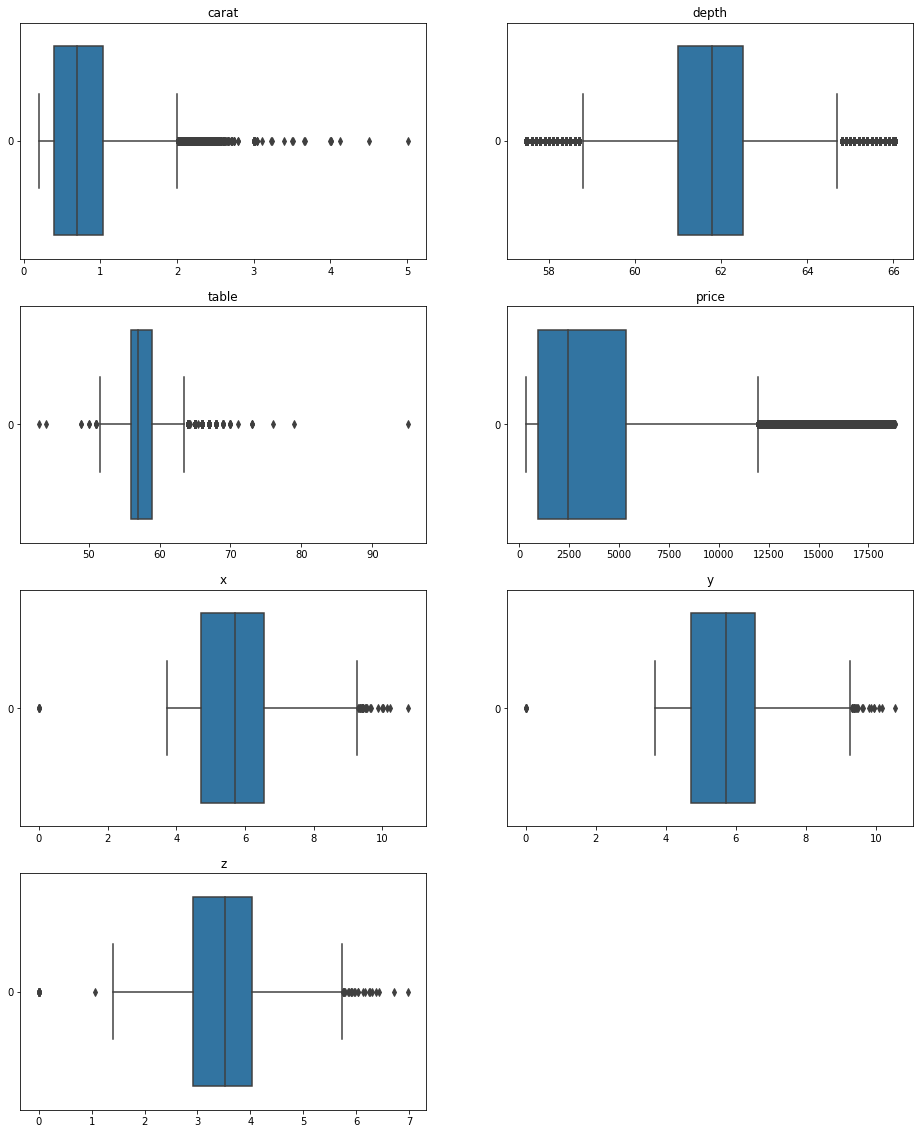

In [17]:
plt.figure(figsize=(16,20))
plt.subplot(4,2,1)
sns.boxplot(df['carat'],orient="horizontal")
plt.title('carat')
plt.subplot(4,2,2)
sns.boxplot(df['depth'],orient="horizontal")
plt.title('depth')
plt.subplot(4,2,3)
sns.boxplot(df['table'],orient="horizontal")
plt.title('table')
plt.subplot(4,2,4)
sns.boxplot(df['price'],orient="horizontal")
plt.title('price')
plt.subplot(4,2,5)
sns.boxplot(df['x'],orient="horizontal")
plt.title('x')
plt.subplot(4,2,6)
sns.boxplot(df['y'],orient="horizontal")
plt.title('y')
plt.subplot(4,2,7)
sns.boxplot(df['z'],orient="horizontal")
plt.title('z')
plt.show()

In [18]:
df[(df.x == df.x.min()) | (df.y == df.y.min()) | (df.z == df.z.min())]

,carat,cut,color,clarity,depth,table,price,x,y,z
2046,1.00,Premium,G,SI2,59.1,59.0,3142,6.55,6.48,0.0
4422,1.10,Premium,G,SI2,63.0,59.0,3696,6.50,6.47,0.0
5038,1.01,Premium,F,SI2,59.2,58.0,3837,6.50,6.47,0.0
9370,1.50,Good,G,I1,64.0,61.0,4731,7.15,7.04,0.0
10310,1.07,Ideal,F,SI2,61.6,56.0,4954,0.00,6.62,0.0
11038,1.00,Very Good,H,VS2,63.3,53.0,5139,0.00,0.00,0.0
12568,1.15,Ideal,G,VS2,59.2,56.0,5564,6.88,6.83,0.0
14731,1.14,Fair,G,VS1,57.5,67.0,6381,0.00,0.00,0.0
22598,2.18,Premium,H,SI2,59.4,61.0,12631,8.49,8.45,0.0
22721,1.56,Ideal,G,VS2,62.2,54.0,12800,0.00,0.00,0.0


In [19]:
print(len(df[df.x == 0]))
print(len(df[df.y == 0]))
print(len(df[df.z == 0]))

7
6
17


As we see there are a few data without specific values  for X and Y dimensions.  

In [20]:
mask =  df[(df.x == 0) & (df.y == 0) & (df.z == 0)]
df = df.drop(mask.index)


In [21]:
print(len(df[df.x == 0]))
print(len(df[df.y == 0]))
print(len(df[df.z == 0]))

1
0
11


Process of deciding what to do with these 11 zeros in z axis

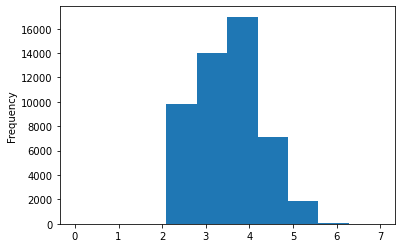

In [22]:
df['z'].plot.hist(bins=10)
plt.show()

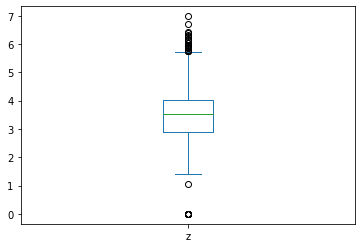

In [23]:
df['z'].plot.box()
plt.show()

In [24]:
df['z'].describe()

count    49865.000000
mean         3.540765
std          0.693830
min          0.000000
25%          2.910000
50%          3.530000
75%          4.040000
max          6.980000
Name: z, dtype: float64

In [25]:
mean_z = df.loc[df['z'] != 0, 'z'].mean()

# replace the 0 values in 'z' with the mean
df.loc[df['z'] == 0, 'z'] = mean_z
print(len(df[df.x == 0]))
print(len(df[df.y == 0]))
print(len(df[df.z == 0]))

1
0
0


In [26]:
mask =  df[df.x == 0]
df = df.drop(mask.index)
print(len(df[df.x == 0]))
print(len(df[df.y == 0]))
print(len(df[df.z == 0]))

0
0
0


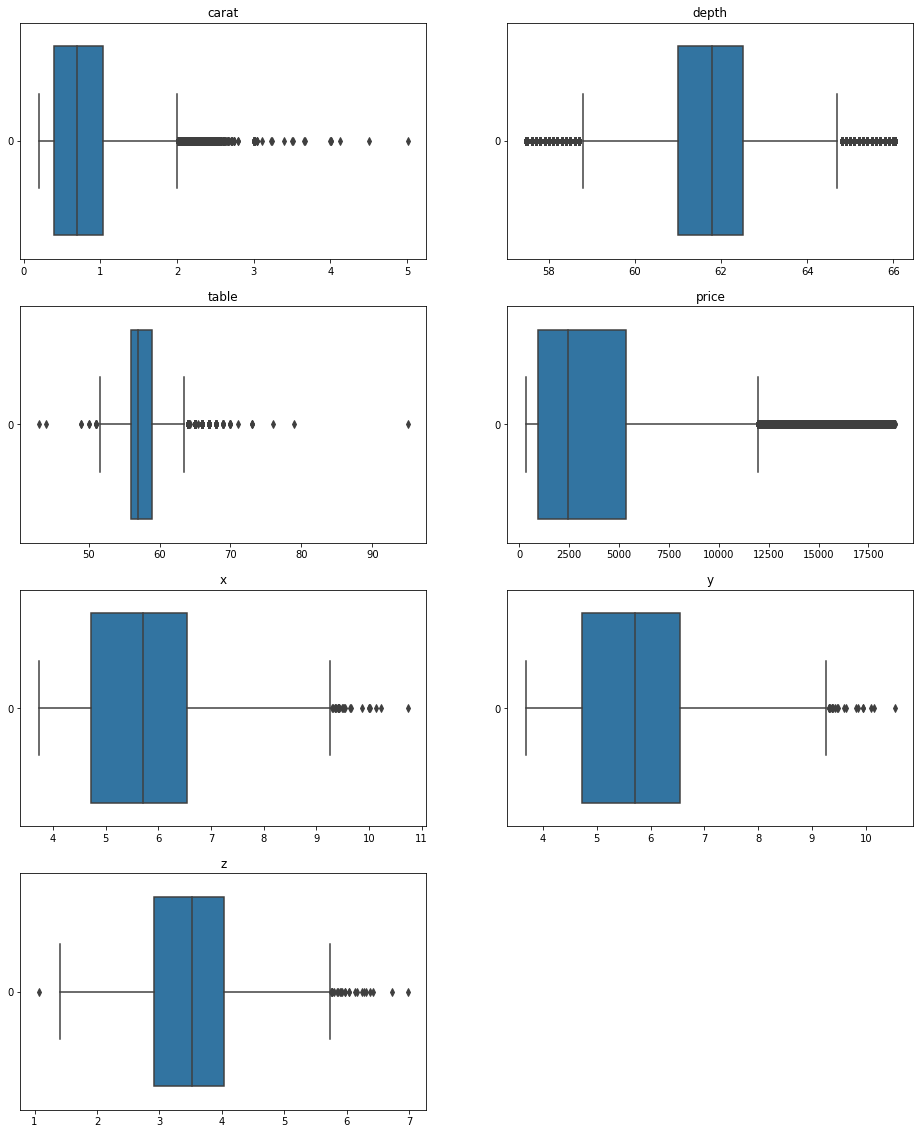

In [27]:
plt.figure(figsize=(16,20))
plt.subplot(4,2,1)
sns.boxplot(df['carat'],orient="horizontal")
plt.title('carat')
plt.subplot(4,2,2)
sns.boxplot(df['depth'],orient="horizontal")
plt.title('depth')
plt.subplot(4,2,3)
sns.boxplot(df['table'],orient="horizontal")
plt.title('table')
plt.subplot(4,2,4)
sns.boxplot(df['price'],orient="horizontal")
plt.title('price')
plt.subplot(4,2,5)
sns.boxplot(df['x'],orient="horizontal")
plt.title('x')
plt.subplot(4,2,6)
sns.boxplot(df['y'],orient="horizontal")
plt.title('y')
plt.subplot(4,2,7)
sns.boxplot(df['z'],orient="horizontal")
plt.title('z')
plt.show()

In [28]:
df['table'].describe()

count    49864.000000
mean        57.458784
std          2.230637
min         43.000000
25%         56.000000
50%         57.000000
75%         59.000000
max         95.000000
Name: table, dtype: float64

In [29]:
mask =  df[df.table == df.table.max()]
df = df.drop(mask.index)

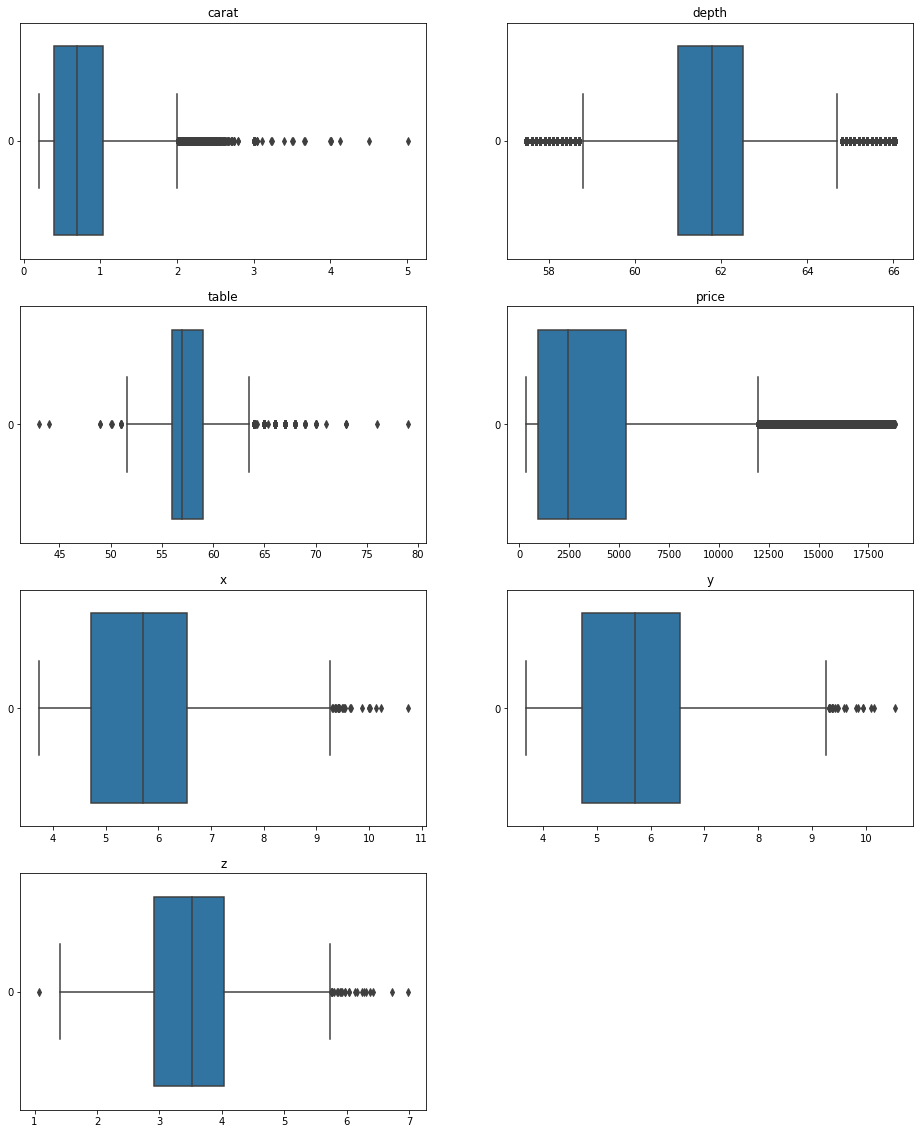

In [30]:
plt.figure(figsize=(16,20))
plt.subplot(4,2,1)
sns.boxplot(df['carat'],orient="horizontal")
plt.title('carat')
plt.subplot(4,2,2)
sns.boxplot(df['depth'],orient="horizontal")
plt.title('depth')
plt.subplot(4,2,3)
sns.boxplot(df['table'],orient="horizontal")
plt.title('table')
plt.subplot(4,2,4)
sns.boxplot(df['price'],orient="horizontal")
plt.title('price')
plt.subplot(4,2,5)
sns.boxplot(df['x'],orient="horizontal")
plt.title('x')
plt.subplot(4,2,6)
sns.boxplot(df['y'],orient="horizontal")
plt.title('y')
plt.subplot(4,2,7)
sns.boxplot(df['z'],orient="horizontal")
plt.title('z')
plt.show()

In [31]:
need_oulier_management = ['table','x','y','z']
for item in need_oulier_management:
    q1 = df[item].quantile(0.25)
    q3 = df[item].quantile(0.75)
    iqr = q3 - q1


    lower_bound = q1 - 1.5*iqr
    upper_bound = q3 + 1.5*iqr

    # replace outliers with the median value
    median = df[item].median()
    df[item] = np.where((df[item] < lower_bound), lower_bound, df[item])
    df[item] = np.where((df[item] > upper_bound), upper_bound, df[item])

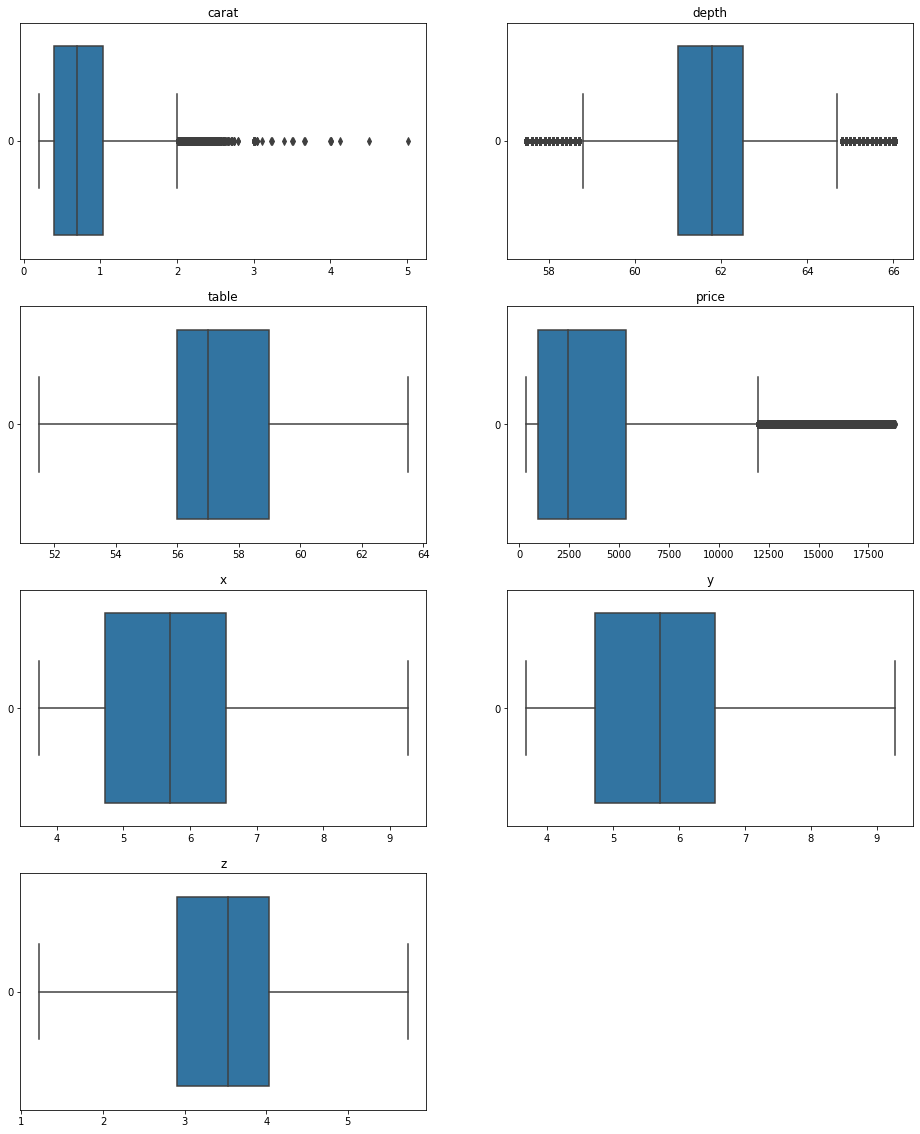

In [32]:
plt.figure(figsize=(16,20))
plt.subplot(4,2,1)
sns.boxplot(df['carat'],orient="horizontal")
plt.title('carat')
plt.subplot(4,2,2)
sns.boxplot(df['depth'],orient="horizontal")
plt.title('depth')
plt.subplot(4,2,3)
sns.boxplot(df['table'],orient="horizontal")
plt.title('table')
plt.subplot(4,2,4)
sns.boxplot(df['price'],orient="horizontal")
plt.title('price')
plt.subplot(4,2,5)
sns.boxplot(df['x'],orient="horizontal")
plt.title('x')
plt.subplot(4,2,6)
sns.boxplot(df['y'],orient="horizontal")
plt.title('y')
plt.subplot(4,2,7)
sns.boxplot(df['z'],orient="horizontal")
plt.title('z')
plt.show()

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler


# scaler = MinMaxScaler()
# df[['x']] = scaler.fit_transform(df[['x']])
# df[['y']] = scaler.fit_transform(df[['y']])
# df[['z']] = scaler.fit_transform(df[['z']])
# df[['table']] = scaler.fit_transform(df[['table']])

# scaler = StandardScaler()
# df[['depth']] = scaler.fit_transform(df[['depth']])
cols_to_minmax = ['x','y','z','table']
scaler = MinMaxScaler()  # or StandardScaler()
scaler.fit(df[cols_to_minmax])
df[cols_to_minmax] = scaler.transform(df[cols_to_minmax])
df_val[cols_to_minmax] = scaler.transform(df_val[cols_to_minmax])

scaler = StandardScaler()
scaler.fit(df[['depth']])
df[['depth']] = scaler.transform(df[['depth']])
df_val[['depth']] = scaler.transform(df_val[['depth']])

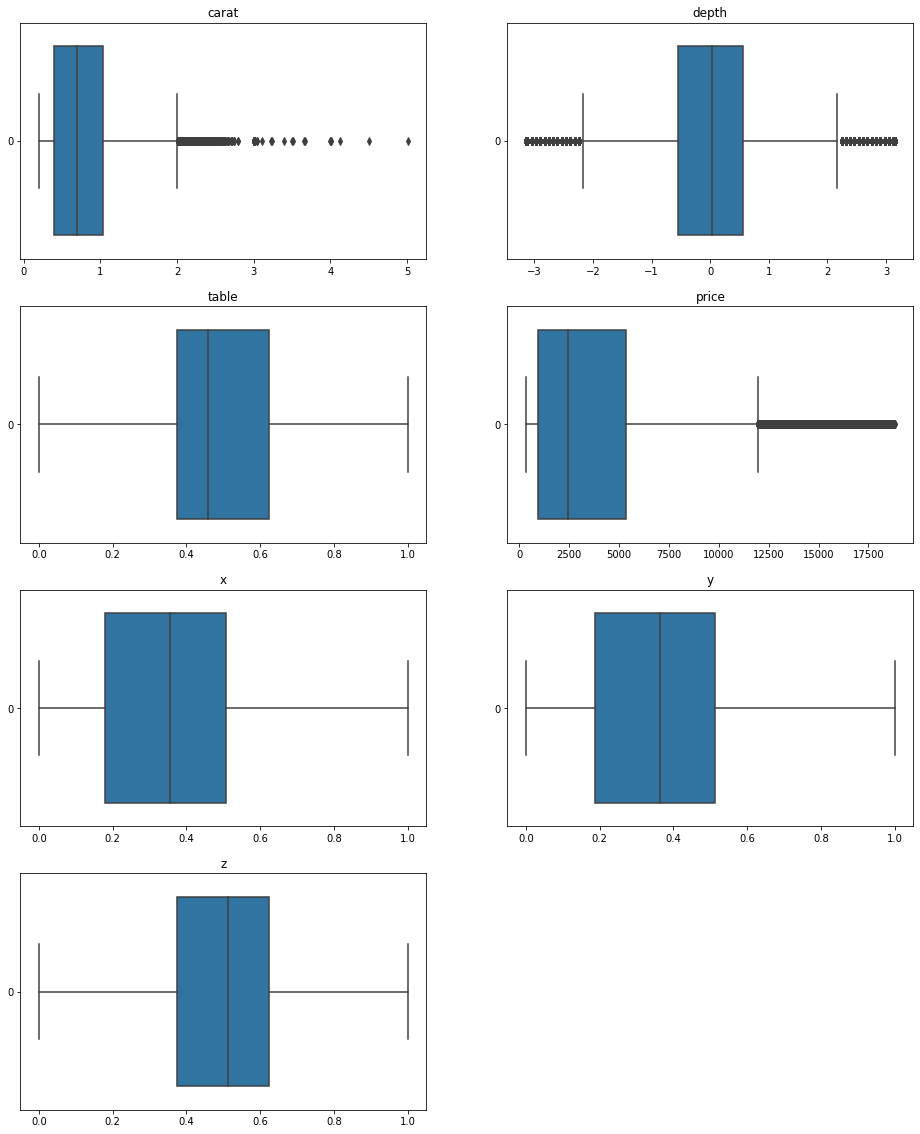

In [34]:
plt.figure(figsize=(16,20))
plt.subplot(4,2,1)
sns.boxplot(df['carat'],orient="horizontal")
plt.title('carat')
plt.subplot(4,2,2)
sns.boxplot(df['depth'],orient="horizontal")
plt.title('depth')
plt.subplot(4,2,3)
sns.boxplot(df['table'],orient="horizontal")
plt.title('table')
plt.subplot(4,2,4)
sns.boxplot(df['price'],orient="horizontal")
plt.title('price')
plt.subplot(4,2,5)
sns.boxplot(df['x'],orient="horizontal")
plt.title('x')
plt.subplot(4,2,6)
sns.boxplot(df['y'],orient="horizontal")
plt.title('y')
plt.subplot(4,2,7)
sns.boxplot(df['z'],orient="horizontal")
plt.title('z')
plt.show()

In [35]:
nominal_cols = ['cut','color','clarity']
for i in nominal_cols:
    print(df[i].value_counts())
    one_hot_encoded = pd.get_dummies(df[i],prefix=i)
    df = pd.concat([df, one_hot_encoded], axis=1)
    one_hot_encoded = pd.get_dummies(df_val[i],prefix=i)
    df_val = pd.concat([df_val, one_hot_encoded], axis=1)
df = df.drop(nominal_cols, axis=1)
df_val = df_val.drop(nominal_cols, axis=1)
df.head()

Ideal        19878
Premium      12766
Very Good    11192
Good          4546
Fair          1481
Name: cut, dtype: int64
G    10422
E     9065
F     8841
H     7680
D     6208
I     5045
J     2602
Name: color, dtype: int64
SI1     12085
VS2     11376
SI2      8479
VS1      7561
VVS2     4687
VVS1     3362
IF       1626
I1        687
Name: clarity, dtype: int64


,carat,depth,table,price,x,y,z,cut_Fair,cut_Good,cut_Ideal,...,color_I,color_J,clarity_I1,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,-0.182351,0.291667,326,0.039711,0.053667,0.268805,0,0,1,...,0,0,0,0,0,1,0,0,0,0
1,0.21,-1.430902,0.791667,326,0.028881,0.028623,0.242257,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0.23,-3.144220,1.000000,327,0.057762,0.069767,0.242257,0,1,0,...,0,0,0,0,0,0,1,0,0,0
3,0.29,0.478647,0.541667,334,0.084838,0.098390,0.313053,0,0,0,...,1,0,0,0,0,0,0,1,0,0
4,0.31,1.139645,0.541667,335,0.110108,0.119857,0.339602,0,1,0,...,0,1,0,0,0,1,0,0,0,0


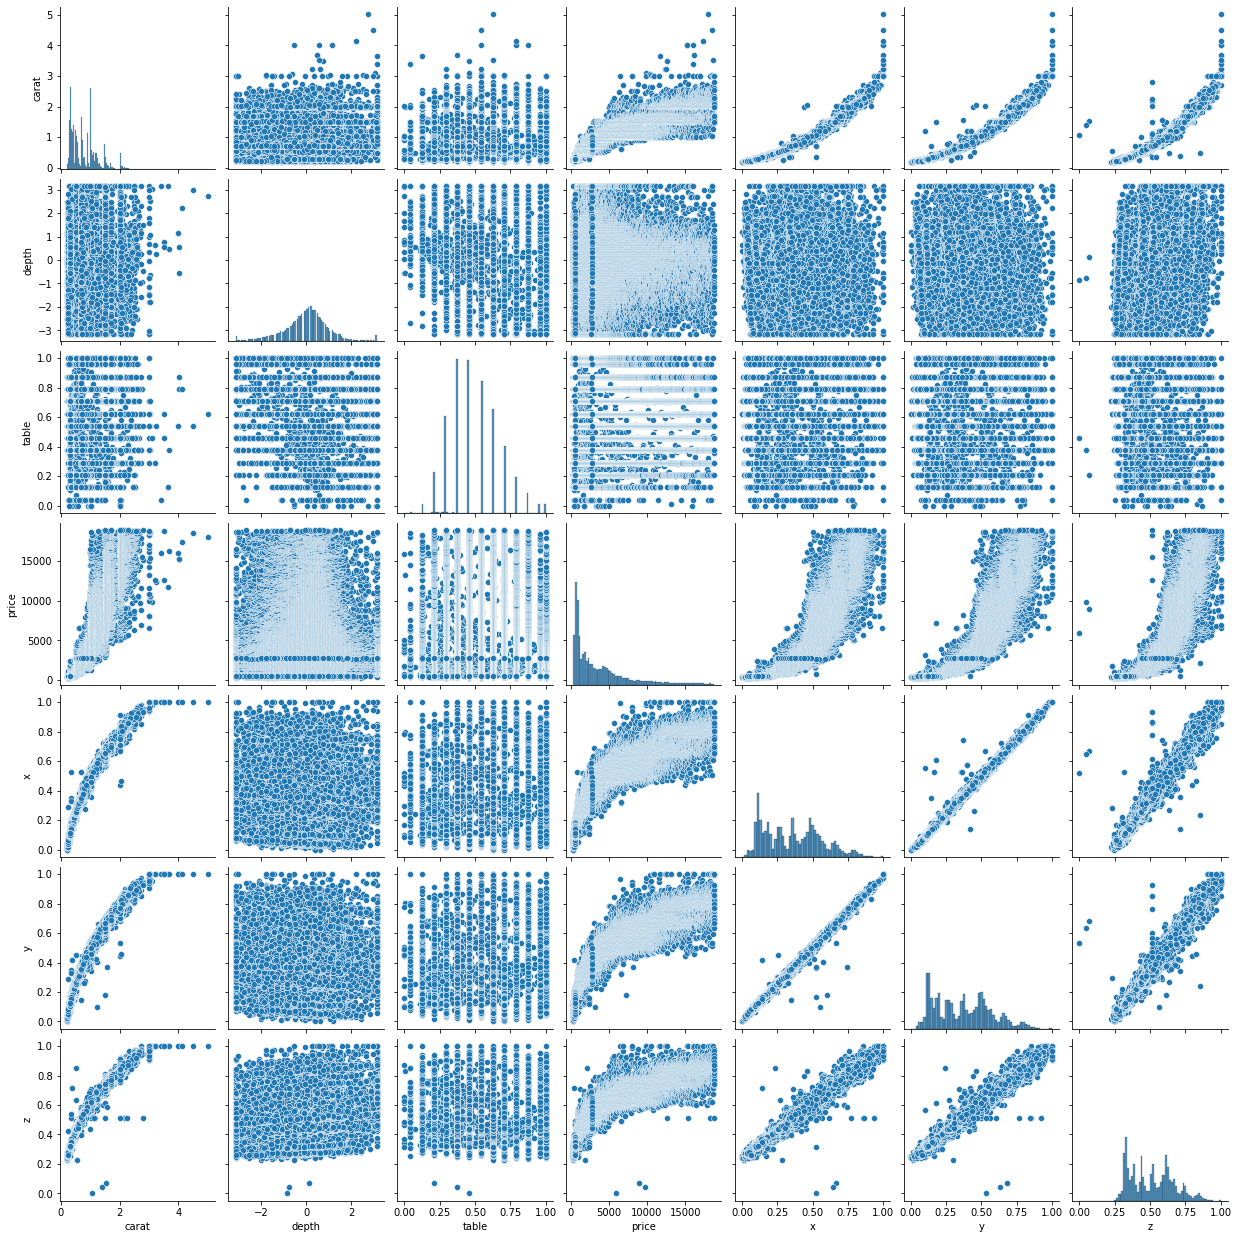

In [36]:
sns.pairplot(df.iloc[:, 0:7])
plt.show()

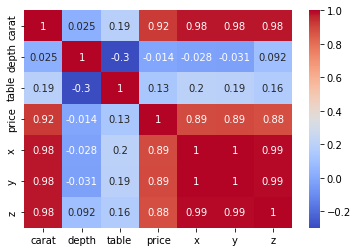

In [37]:
corr_matrix = df.iloc[:,0:7].corr()

# plot the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [38]:
del df['y']
del df_val['y']

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">

</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazir" size=3>
    حال که داده‌ها را پاکسازی کرده و احتمالا ویژگی‌هایی را به آن افزوده یا از آن حذف کرده‌اید، وقت آن است که مدلی آموزش دهید که بتواند متغیر هدف این مسئله را پیش‌بینی کند.
    الگوریتم <code>LinearRegression</code> نیز در کتابخانه‌ی <code>scikit-learn</code> به‌خوبی پیاده‌سازی شده و می‌توانیم از آن جهت اجرای الگوریتم <i>رگرسیون خطی</i> بر روی داده‌های خود کمک بگیریم.
</font>
</p>

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
آموزش مدل
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
    در سلول پایین با استفاده از کتابخانه <code>scikit-learn</code> مدلی آموزش دهید که بتواند متغیر هدف این مسئله را پیش‌بینی کند.
    <br>
    <b>حتما باید از مدل رگرسیون خطی یعنی <code>LinearRegression</code> استفاده کنید.</b>
</font>
</p>

In [39]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [40]:
y_train = df['price']
X_train = df.loc[:, df.columns != 'price']
X_train

,carat,depth,table,x,z,cut_Fair,cut_Good,cut_Ideal,cut_Premium,cut_Very Good,...,color_I,color_J,clarity_I1,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,-0.182351,0.291667,0.039711,0.268805,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0.21,-1.430902,0.791667,0.028881,0.242257,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
2,0.23,-3.144220,1.000000,0.057762,0.242257,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,0.29,0.478647,0.541667,0.084838,0.313053,0,0,0,1,0,...,1,0,0,0,0,0,0,1,0,0
4,0.31,1.139645,0.541667,0.110108,0.339602,0,1,0,0,0,...,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,0.72,-0.696460,0.458333,0.364621,0.505531,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
49996,0.72,0.992756,0.291667,0.353791,0.529867,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
49997,0.70,0.772424,0.708333,0.348375,0.518805,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
49998,0.86,-0.549571,0.541667,0.436823,0.558628,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0


In [41]:
model.fit(X_train, y_train)

LinearRegression()

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
معیار ارزیابی
</font>
</h3>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
    معیاری که برای ارزیابی عملکرد مدل انتخاب کرده‌ایم، <code>r2_score</code> نام دارد.
    <br>
    این معیار، سنجه ارزیابی کیفیت مدل شماست. به عبارت بهتر در سامانه داوری هم از همین معیار برای نمره‌دهی استفاده شده است.
    <br>
    پیشنهاد می‌شود با توجه به این معیار، عملکرد مدل خود را بر روی مجموعه‌ی آموزش یا اعتبارسنجی ارزیابی کنید.
</font>
</p>

In [42]:
from sklearn.metrics import r2_score

y_train = df['price']
X_train = df.loc[:, df.columns != 'price']


# r2_score(y_true, y_pred)
# To-Do

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font color="red"><b color='red'>توجه:</b></font>
<font face="vazir" size=3>
 جهت کسب امتیاز کامل نیاز است تا پاسخ شما حداقل امتیاز <code>80</code> را با توجه به معیار معرفی‌شده کسب نماید.
</font>
</p>

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
 پیش‌بینی برای داده تست و خروجی
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazir" size=3>
    پس از مهندسی ویژگی و مدل‌سازی، الگوریتمی دارید که می‌تواند شما را از متغیرهای مستقل به متغیر هدف برساند.
    <br>
    از این مدل برای پیش‌بینی نمونه‌های موجود در داده تست استفاده کنید و نتایج را در قالب جدول زیر آماده کنید.
</font>
</p>

<center>
<div dir=rtl style="line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
    
|ستون|توضیحات|
|:------:|:---:|
|<code>price</code>|قیمت پیش‌بینی‌شده برای الماس|
    
</font>
</div>
</center>


<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazir" size=3>
توجه داشته باشید که:
</font>
</p>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium; margin-right:48px">
<font face="vazir" size=3>
    ۱. نام دیتافریم پاسخ شما حتماً باید <code>submission</code> باشد، در غیر این‌صورت سامانه‌ی داوری نمی‌تواند تلاش شما را ارزیابی کند.
    <br>
    ۲. این دیتافریم تنها شامل یک ستون با نام <code>price</code> بوده و شامل ۳۹۴۰ ردیف است.
    <br>
    ۳. ترتیب ردیف‌های دیتافریم باید دقیقاً مطابق با نمونه‌های آزمون باشد. یعنی به‌عنوان مثال اولین ردیف شما باید پیش‌بینی مدل‌تان برای نمونه‌ی آزمون اول باشد.
</font>
</p>

In [43]:
test.head()

,carat,cut,color,clarity,depth,table,x,y,z
0,0.73,Ideal,G,VVS2,61.9,55.0,5.83,5.77,3.59
1,0.61,Premium,F,VVS2,59.7,58.0,5.56,5.53,3.31
2,1.55,Premium,I,VS1,58.2,60.0,7.69,7.59,4.45
3,0.46,Good,F,IF,56.2,61.0,5.16,5.24,2.92
4,1.10,Very Good,F,VS2,60.6,58.0,6.67,6.77,4.07


In [46]:

price = model.predict(df_val)
# predict test samples
price
submission = pd.DataFrame({'price': price})


<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
<b>سلول جواب‌ساز</b>
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazir" size=3>
    برای ساخته‌شدن فایل <code>result.zip</code> سلول زیر را اجرا کنید. توجه داشته باشید که پیش از اجرای سلول زیر تغییرات اعمال شده در نت‌بوک را ذخیره کرده باشید (<code>ctrl+s</code>) تا در صورت نیاز به پشتیبانی امکان بررسی کد شما وجود داشته باشد.
</font>
</p>

In [47]:
import zipfile
import joblib

def compress(file_names):
    print("File Paths:")
    print(file_names)
    compression = zipfile.ZIP_DEFLATED
    with zipfile.ZipFile("result.zip", mode="w") as zf:
        for file_name in file_names:
            zf.write('./' + file_name, file_name, compress_type=compression)

submission.to_csv('submission.csv', index=False)
joblib.dump(model, 'model')
file_names = ['diamond.ipynb', 'submission.csv', 'model']
compress(file_names)

File Paths:
['diamond.ipynb', 'submission.csv', 'model']


<h4 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
<b>راهنمایی</b>
</font>
</h4>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazir" size=3>
    ۱. ستون‌های دسته‌ای (<i>categorical</i>) دیتافریم را می‌توانید <code>labelEncode</code> کنید.
    <br>
    ۲. فراموش نکنید که مراحل پیش‌پردازش خود را بر روی نمونه‌های آزمون نیز اعمال کنید.
</font>
</p>